<a href="https://colab.research.google.com/github/projectgroup398-sudo/NorthStar_Section2_R_Analytics/blob/main/NorthStar_Section2_R_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Enable R

In [ ]:
!apt-get install -y r-base
!pip install rpy2 pandas matplotlib seaborn

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
r-base is already the newest version (4.5.3-1.2204.0).
0 upgraded, 0 newly installed, 0 to remove and 6 not upgraded.


# Upload CSV Files

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving app_events.csv to app_events.csv
Saving complaints.csv to complaints.csv
Saving customers.csv to customers.csv
Saving data_dictionary.csv to data_dictionary.csv
Saving deliveries.csv to deliveries.csv
Saving drivers.csv to drivers.csv
Saving hubs.csv to hubs.csv
Saving incidents.csv to incidents.csv
Saving orders.csv to orders.csv
Saving vehicles.csv to vehicles.csv


# Load R Extension

In [ ]:
%load_ext rpy2.ipython

# Install Required R Libraries

In [ ]:
%%R

install.packages("ggplot2")
install.packages("dplyr")
install.packages("corrplot")

library(ggplot2)
library(dplyr)
library(corrplot)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cran.rstudio.com/src/contrib/ggplot2_4.0.2.tar.gz'
Content type 'application/x-gzip' length 6358661 bytes (6.1 MB)
downloaded 6.1 MB


The downloaded source packages are in
	‘/tmp/Rtmp8IZsdM/downloaded_packages’
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cran.rstudio.com/src/contrib/dplyr_1.2.0.tar.gz'
Content type 'application/x-gzip' length 922393 bytes (900 KB)
downloaded 900 KB


The downloaded source packages are in
	‘/tmp/Rtmp8IZsdM/downloaded_packages’
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cran.rstudio.com/src/contrib/corrplot_0.95.tar.gz'
Content type 'application/x-gzip' length 3745190 bytes (3.6 MB)
downloaded 3.6 MB


The downloaded source packages are in
	‘/tmp/Rtmp8IZsdM/downloaded_packages’

Attaching package: ‘dplyr’

The following objects are masked

# Load Data into R

In [ ]:
%%R

customer <- read.csv("customers.csv")
orders <- read.csv("orders.csv")
drivers <- read.csv("drivers.csv")
vehicle <- read.csv("vehicles.csv")
complaint <- read.csv("complaints.csv")
app_event <- read.csv("app_events.csv")
incidents <- read.csv("incidents.csv")

head(customer)

  customer_id age home_zone customer_type         signup_date loyalty_score
1       C0001  26     North           SME 2024-11-27 04:25:00          44.9
2       C0002  61   AIRPORT      Consumer 2025-10-28 01:04:00          55.4
3       C0003  66      East      Consumer 2025-07-02 03:23:00          75.9
4       C0004  75   CENTRAL      Consumer 2025-08-19 01:58:00          32.5
5       C0005  26 Riverside      Consumer 2025-06-03 06:02:00          55.9
6       C0006  41      WEST      Consumer 2024-03-29 13:26:00          39.9
  app_engagement_score preferred_channel account_status
1                 69.2               App         Active
2                 66.6               App         Active
3                 33.8                           Active
4                 33.0               App         Active
5                100.0               Web         Active
6                 43.3               Web         Active


# Data Preparation

In [ ]:
%%R

customer$home_zone <- toupper(customer$home_zone)
drivers$base_zone <- toupper(drivers$base_zone)
orders$pickup_zone <- toupper(orders$pickup_zone)
vehicle$assigned_zone <- toupper(vehicle$assigned_zone)
app_event$zone_context <- toupper(app_event$zone_context)

# Analysis 1 – Customer Engagement vs Loyalty Score (Correlation)

Objective

Identify whether customer engagement with the app influences loyalty score.

                     loyalty_score app_engagement_score
loyalty_score           1.00000000           0.03566776
app_engagement_score    0.03566776           1.00000000


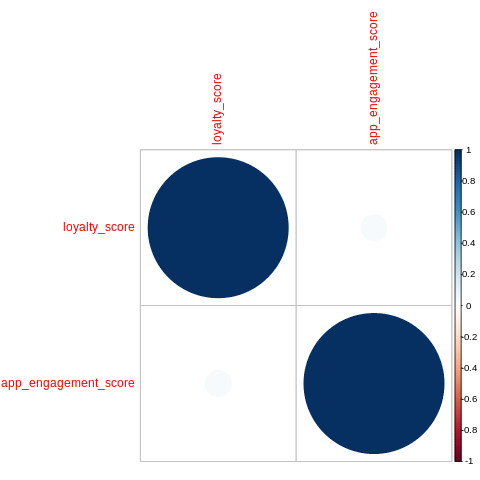

In [ ]:
%%R

correlation_data <- customer %>%
select(loyalty_score, app_engagement_score)

correlation_matrix <- cor(correlation_data, use="complete.obs")

corrplot(correlation_matrix, method="circle")

correlation_matrix

# Analysis 2 – Order Value Distribution by Service Type

Objective

Understand revenue patterns across service categories.

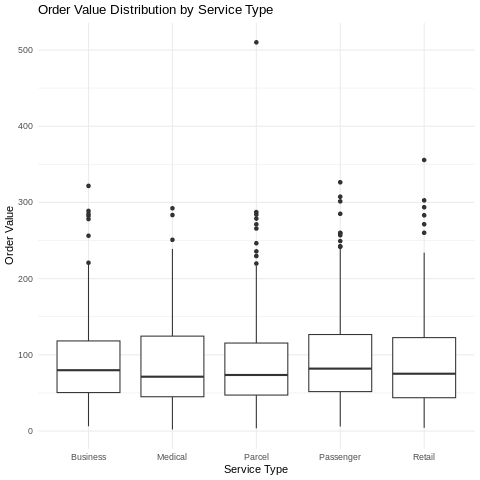

In [ ]:
%%R

ggplot(orders, aes(x=service_type, y=order_value)) +
geom_boxplot() +
theme_minimal() +
labs(title="Order Value Distribution by Service Type",
x="Service Type",
y="Order Value")

# Analysis 3 – Driver Experience vs Driver Rating

Objective

Evaluate whether experienced drivers receive higher performance ratings.

`geom_smooth()` using formula = 'y ~ x'


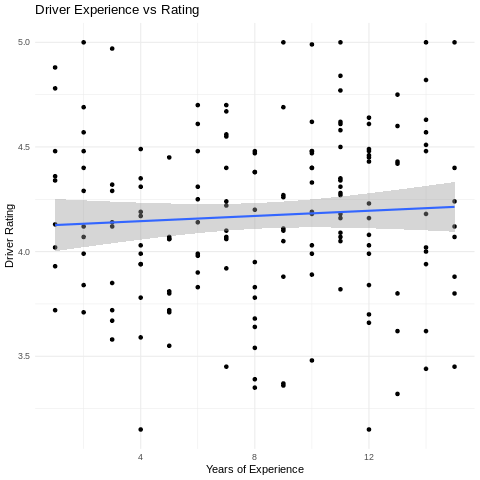

In [ ]:
%%R

ggplot(drivers, aes(x=years_experience, y=driver_rating)) +
geom_point() +
geom_smooth(method="lm") +
theme_minimal() +
labs(title="Driver Experience vs Rating",
x="Years of Experience",
y="Driver Rating")

# Analysis 4 – Complaint Severity Distribution

Objective

Understand the frequency of different complaint severity levels.

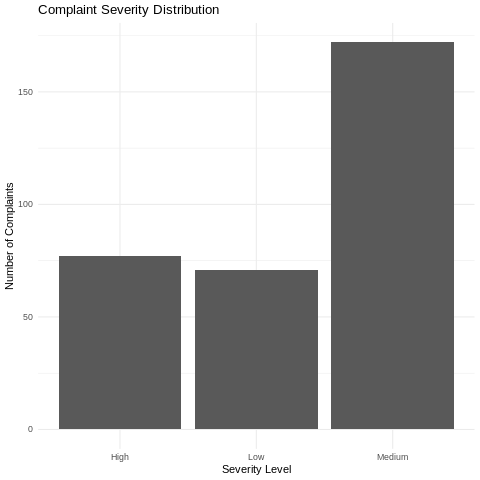

In [ ]:
%%R

ggplot(complaint, aes(x=severity)) +
geom_bar() +
theme_minimal() +
labs(title="Complaint Severity Distribution",
x="Severity Level",
y="Number of Complaints")

# Analysis 5 – App Latency Distribution by Device Type

Objective

Evaluate whether device type influences application performance.

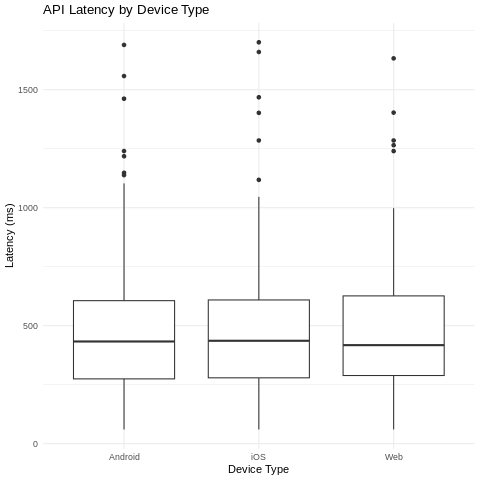

In [ ]:
%%R

ggplot(app_event, aes(x=device_type, y=api_latency_ms)) +
geom_boxplot() +
theme_minimal() +
labs(title="API Latency by Device Type",
x="Device Type",
y="Latency (ms)")

# Analysis 6 – Incident Resolution Time by Severity

Objective

Understand operational risk impact.


(`stat_boxplot()`). 



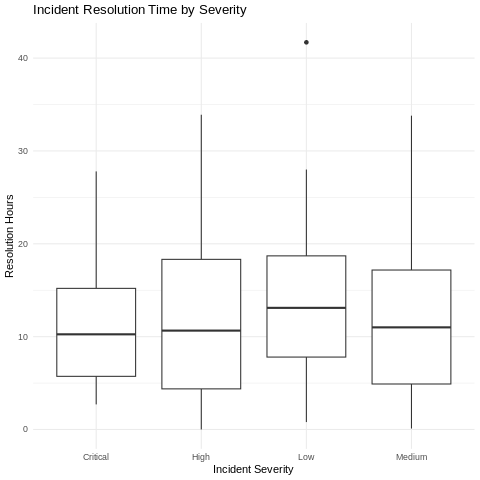

In [ ]:
%%R

ggplot(incidents, aes(x=severity, y=resolved_hours)) +
geom_boxplot() +
theme_minimal() +
labs(title="Incident Resolution Time by Severity",
x="Incident Severity",
y="Resolution Hours")